In [27]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [28]:
tf.test.is_gpu_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/Machine_Learning_WAI/cats_and_dogs_filtered.zip

Archive:  /content/drive/MyDrive/Machine_Learning_WAI/cats_and_dogs_filtered.zip
   creating: cats_and_dogs_filtered/
  inflating: cats_and_dogs_filtered/.DS_Store  
   creating: cats_and_dogs_filtered/test/
   creating: cats_and_dogs_filtered/train/
   creating: cats_and_dogs_filtered/test/dogs/
   creating: cats_and_dogs_filtered/test/cats/
  inflating: cats_and_dogs_filtered/test/.DS_Store  
   creating: cats_and_dogs_filtered/train/dogs/
   creating: cats_and_dogs_filtered/train/cats/
  inflating: cats_and_dogs_filtered/train/.DS_Store  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2448.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2460.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2461.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2449.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2463.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2462.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2466.jpg  
  inflating: cats_and_dog

In [29]:
root_dir = r"/content/cats_and_dogs_filtered"

In [33]:
BATCH_SIZE  = 64
EPOCHS = 50
input_img_size = (150,150)
input_shape = (150,150,3)

In [34]:
# Data Augmentation
tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


train_ds = tf_generator.flow_from_directory(
    root_dir + "/train",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_ds = tf_generator.flow_from_directory(
    root_dir + "/test",
    target_size=input_img_size,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 2752 images belonging to 2 classes.
Found 248 images belonging to 2 classes.


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),  # Prevent overfitting
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Correct activation for binary
])

optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',  # Correct loss for binary
              metrics=['accuracy'])


In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # stop after 5 epochs of no improvement
    restore_best_weights=True
)


In [37]:


model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,596,481 (36.61 MB)

 Trainable params: 9,596,481 (36.61 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(train_ds,epochs=EPOCHS, validation_data=val_ds,callbacks=[early_stop],verbose=1)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 533ms/step - accuracy: 0.5064 - loss: 0.7035 - val_accuracy: 0.5806 - val_loss: 0.6863
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 466ms/step - accuracy: 0.5307 - loss: 0.6838 - val_accuracy: 0.5040 - val_loss: 0.6837
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.5758 - loss: 0.6732 - val_accuracy: 0.6210 - val_loss: 0.6656
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 471ms/step - accuracy: 0.5785 - loss: 0.6673 - val_accuracy: 0.6452 - val_loss: 0.6452
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 434ms/step - accuracy: 0.6046 - loss: 0.6484 - val_accuracy: 0.6169 - val_loss: 0.6379
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 461ms/step - accuracy: 0.6249 - loss: 0.6413 - val_accuracy: 0.5524 - val_loss: 0.6656
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 433ms/step - accuracy: 0.6296 - loss: 0.6379 - val_accuracy: 0.6492 - val_loss: 0.6095
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 542ms/step - accuracy: 0.6572 - loss: 0.6163 - val_accu

In [39]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - accuracy: 0.7108 - loss: 0.5274
Validation Loss: 0.5524
Validation Accuracy: 0.6976


In [40]:
BATCH_SIZE
input_shape

(150, 150, 3)

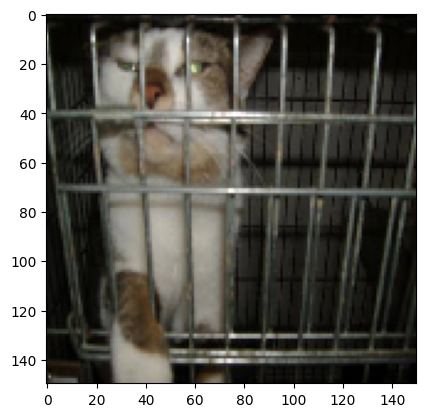

In [41]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"/content/cats_and_dogs_filtered/test/cats/cat.2366.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [47]:

class_names = list(train_ds.class_indices.keys())


class_indices = {name: idx for idx, name in enumerate(class_names)}
print("Class names found:", class_indices)

Class names found: {'cats': 0, 'dogs': 1}


In [49]:
class_names

['cats', 'dogs']

In [50]:
model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step


np.float32(0.16450517)

In [51]:
prediction = model.predict(img_array)[0][0]
class_name = "dogs" if prediction > 0.5 else "cats"

print(f"Predicted class: {class_name} with confidence {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted class: cats with confidence 0.16


### Model Saving

In [54]:

ML_Summer_School_ID = "ML041_Htet Khant Linn"
print("Your Sudent ID is: " + ML_Summer_School_ID)

Your Sudent ID is: ML041_Htet Khant Linn


In [55]:
model.save(f'./binary_classification/{ML_Summer_School_ID}_model.h5')

In [57]:
import json
import os


output_filename = f'./binary_classification/{ML_Summer_School_ID}_class_indices.json'

os.makedirs(os.path.dirname(output_filename), exist_ok=True)

# Save the class_indices dictionary directly to the JSON file
with open(output_filename, 'w') as f:
    # Get the dictionary directly from the generator and dump it
    json.dump(train_ds.class_indices, f)

print(f"Successfully saved class indices to {output_filename}")

Successfully saved class indices to ./binary_classification/ML041_Htet Khant Linn_class_indices.json
